In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND4_nterms2/load_band4_data_nterms2.py"

path = band4_nterms2_data_folder_path

B4 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy,
    StokesI_mJy,
    RA_centre_pix, Dec_centre_pix
)

band = Band 4 nterms2
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 
Biased


In [4]:
# # Import the pre-clean image as well
# StokesI_BC_file = loc + "BAND4_v2_before_clean.fits"
# _, _, StokesI_BC_Jy, _ = read_in_file(StokesI_BC_file)
# StokesI_BC_mJy = convert_jy_to_mjy(StokesI_BC_Jy)

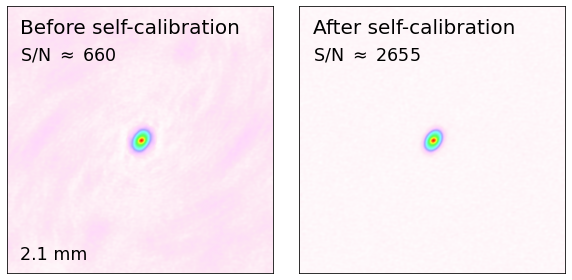

In [16]:
band = B4


fig, ax = plt.subplots(1, 2, figsize=(10, 5),
                       gridspec_kw={'wspace': 0.1},  # Increase wspace for more horizontal space
                       subplot_kw={'projection': band['StokesI_wcs']})

vmin = min(np.nanmin(StokesI_stretched_beforeclean_mJy), np.nanmin(StokesI_stretched_mJy))
vmax = max(np.nanmax(StokesI_stretched_beforeclean_mJy), np.nanmax(StokesI_stretched_mJy))


im0 = ax[0].imshow(StokesI_stretched_beforeclean_mJy, cmap=soft_colormap_v2, vmin=vmin, vmax=vmax)
im1 = ax[1].imshow(StokesI_stretched_mJy, cmap=soft_colormap_v2, vmin=vmin, vmax=vmax)


extra = 300
# --- Shared formatting for all axes ---
for i in range(2):
    # Axis limits and labels
    ax[i].set_xlim(xmin - extra, xmax + extra)
    ax[i].set_ylim(ymin - extra, ymax + extra)

    
    # No x- and y- axis labels
    ax[i].set_xlabel(' ', fontsize = 0)
    ax[i].set_ylabel(' ', fontsize = 0)

    #ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", labelbottom = False, bottom=False, top=False, length=7, labelsize = 0)
    ax[i].tick_params(axis="y", which="major", direction="in", labelleft = False, left=False, right=False, length=7, labelsize = 0)


# Add label on whcih one is clean or not
y_top = 0.9
ax[0].text(0.05, y_top, r'Before self-calibration',
           transform=ax[0].transAxes,
           fontsize=20)

ax[1].text(0.05, y_top, r'After self-calibration',
           transform=ax[1].transAxes,
           fontsize=20)



# Add S/N text
# 565 - 750
diff = 0.1
fs = 17.5
ax[0].text(0.05, y_top - diff, r'S/N $\approx$ 660',
           transform=ax[0].transAxes,
           fontsize=fs)

ax[1].text(0.05, y_top - diff, r'S/N $\approx$ 2655',
           transform=ax[1].transAxes,
           fontsize=fs)

ax[0].text(0.05, 0.05, r'2.1 mm',
           transform=ax[0].transAxes,
           fontsize=fs)

# ax[1].text(0.05, y_top - diff, r'test',
#            transform=ax[1].transAxes,
#            fontsize=fs)

plt.savefig(image_folder_path + '/WRITEUP/' + "BeforeAndAfterClean.png", 
            dpi=500, 
            bbox_inches='tight',
               facecolor='white')